# 06 — Model Comparison (CTRS-R Bar Chart)

Compare any number of evaluated models side-by-side on the CTRS-R rubric.

Just add model names to the `MODELS` list below — each must have a corresponding
`reports/<model_name>/ctsr_eval_scores.csv` from notebook 05.

In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Configuration

Add or remove model names. Each must have been evaluated with notebook 05.

In [17]:
# ── Models to compare ─────────────────────────────────────────────────────────
# Each entry is the folder name under reports/ (same as MODEL_NAME in notebook 05)
MODELS = [
    "base",
    "Qwen3.5-4B-SFT-newdata",
    "Qwen3.5-4B-SFT-CACTUS-iter_02",
]

REPORTS_DIR = Path("../reports")

# ── CTRS-R item keys and labels ───────────────────────────────────────────────
ITEM_KEYS = [
    "item_1_agenda", "item_2_feedback", "item_3_understanding",
    "item_4_interpersonal_effectiveness", "item_5_collaboration",
    "item_6_pacing", "item_7_guided_discovery",
    "item_8_focus_cognitions_behaviors", "item_9_strategy_for_change",
    "item_10_application_cbt_technique", "item_11_action_plan",
]

ITEM_LABELS = [
    "Agenda", "Feedback", "Understanding", "Interpersonal\nEffect.",
    "Collaboration", "Pacing", "Guided\nDiscovery",
    "Focus on Key\nCog. & Beh.", "Strategy\nfor Change",
    "Application\nof CBT Tech.", "Action\nPlan",
]

# Verify all reports exist
for name in MODELS:
    csv_path = REPORTS_DIR / name / "ctsr_eval_scores.csv"
    assert csv_path.exists(), f"Missing: {csv_path}"
    print(f"  ✓ {name}: {csv_path}")
print(f"\nComparing {len(MODELS)} models.")

  ✓ base: ../reports/base/ctsr_eval_scores.csv
  ✓ Qwen3.5-4B-SFT-newdata: ../reports/Qwen3.5-4B-SFT-newdata/ctsr_eval_scores.csv
  ✓ Qwen3.5-4B-SFT-CACTUS-iter_02: ../reports/Qwen3.5-4B-SFT-CACTUS-iter_02/ctsr_eval_scores.csv

Comparing 3 models.


## Load Scores

In [18]:
# Load all score CSVs
dfs = {}
for name in MODELS:
    csv_path = REPORTS_DIR / name / "ctsr_eval_scores.csv"
    df = pd.read_csv(csv_path)
    dfs[name] = df
    print(f"{name}: {len(df)} scored transcripts, mean={df[ITEM_KEYS].mean().mean():.2f}")

# Compute per-item means for each model
means = {name: df[ITEM_KEYS].mean() for name, df in dfs.items()}
means_df = pd.DataFrame(means).T
means_df.columns = ITEM_LABELS
print("\nPer-item means:")
means_df

base: 100 scored transcripts, mean=2.24
Qwen3.5-4B-SFT-newdata: 100 scored transcripts, mean=2.36
Qwen3.5-4B-SFT-CACTUS-iter_02: 100 scored transcripts, mean=2.57

Per-item means:


,Agenda,Feedback,Understanding,Interpersonal\nEffect.,Collaboration,Pacing,Guided\nDiscovery,Focus on Key\nCog. & Beh.,Strategy\nfor Change,Application\nof CBT Tech.,Action\nPlan
base,0.88,0.80,2.68,2.83,1.96,2.04,2.90,2.92,2.55,2.95,2.17
Qwen3.5-4B-SFT-newdata,0.94,0.99,2.71,2.92,2.32,2.29,2.92,2.95,2.65,2.94,2.32
Qwen3.5-4B-SFT-CACTUS-iter_02,1.29,1.40,2.75,2.89,2.85,2.55,2.90,2.99,2.89,2.98,2.73


## Comparison Bar Chart

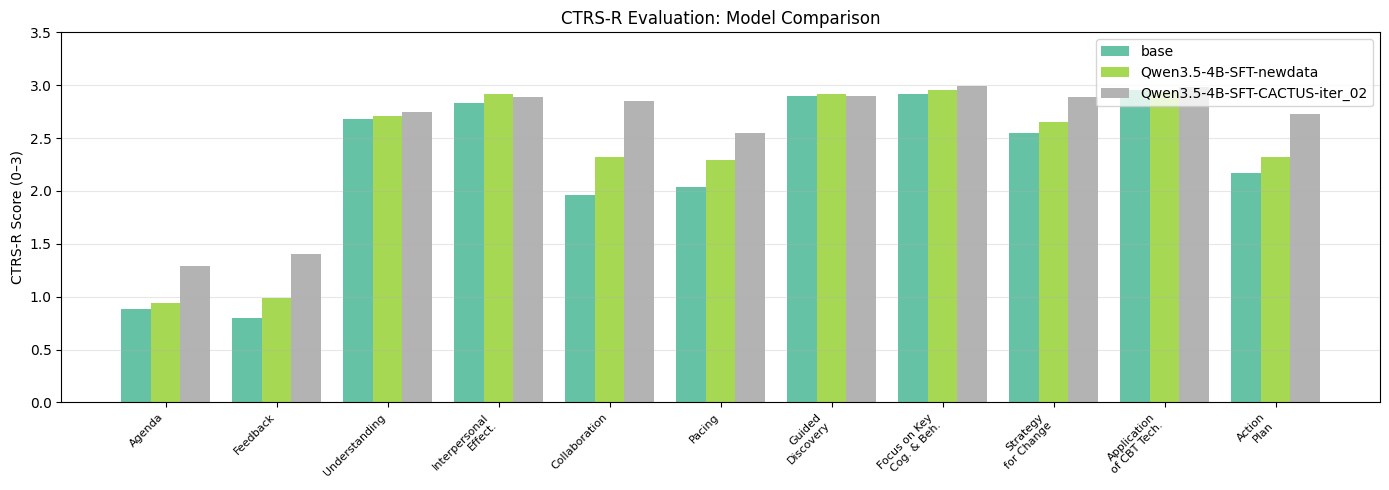

Chart saved → ../reports/ctsr_comparison_chart.png


In [19]:
n_items = len(ITEM_KEYS)
n_models = len(MODELS)
x = np.arange(n_items)
width = 0.8 / n_models  # bar width scales with number of models

# Color palette
colors = plt.cm.Set2(np.linspace(0, 1, max(n_models, 3)))

fig, ax = plt.subplots(figsize=(14, 5))

for i, name in enumerate(MODELS):
    offset = (i - n_models / 2 + 0.5) * width
    model_means = means[name].values
    ax.bar(x + offset, model_means, width, label=name, color=colors[i])

ax.set_ylabel("CTRS-R Score (0–3)")
ax.set_title("CTRS-R Evaluation: Model Comparison")
ax.set_xticks(x)
ax.set_xticklabels(ITEM_LABELS, rotation=45, ha="right", fontsize=8)
ax.set_ylim(0, 3.5)
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

chart_path = REPORTS_DIR / "ctsr_comparison_chart.png"
fig.savefig(chart_path, dpi=150)
plt.show()
print(f"Chart saved → {chart_path}")

## Overall Mean Comparison

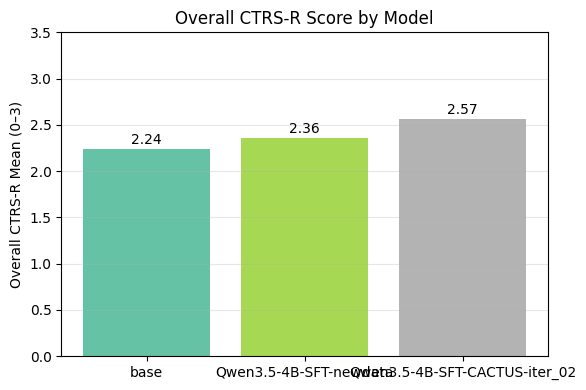


Overall means:
  base: 2.244
  Qwen3.5-4B-SFT-newdata: 2.359
  Qwen3.5-4B-SFT-CACTUS-iter_02: 2.565


In [20]:
# Overall mean per model
overall = {name: df[ITEM_KEYS].mean().mean() for name, df in dfs.items()}

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(overall.keys(), overall.values(), color=colors[:n_models])
ax.set_ylabel("Overall CTRS-R Mean (0–3)")
ax.set_title("Overall CTRS-R Score by Model")
ax.set_ylim(0, 3.5)
ax.grid(axis="y", alpha=0.3)

for bar, val in zip(bars, overall.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{val:.2f}", ha="center", fontsize=10)

fig.tight_layout()
plt.show()

print("\nOverall means:")
for name, val in overall.items():
    print(f"  {name}: {val:.3f}")

## Head-to-Head Comparison (Win/Tie/Loss)

Compare two models per-vignette: for each CTRS-R item, count how often each model scored higher (win), tied, or scored lower. Displayed as horizontal stacked bars summing to 100%.

Shared vignettes: 100


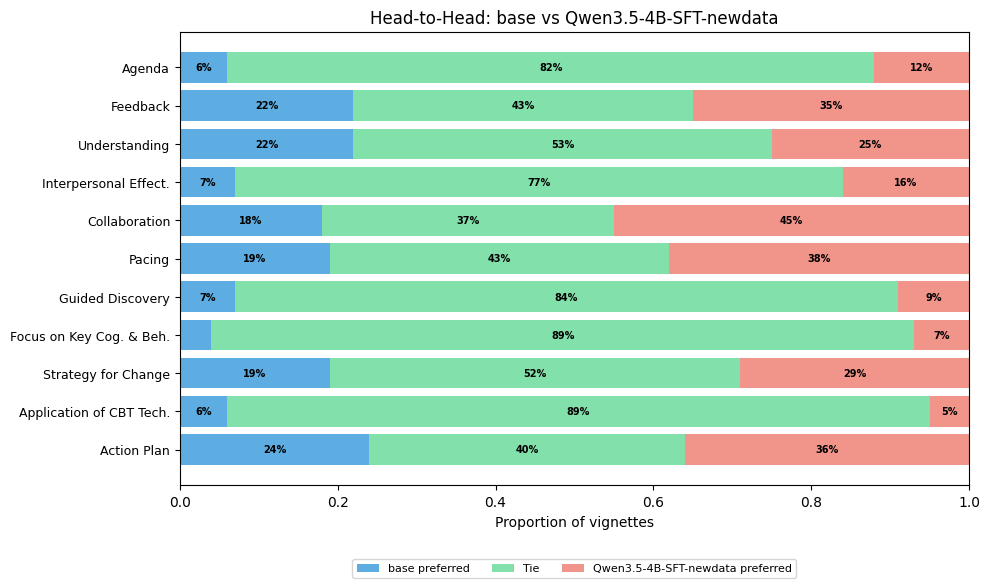

Chart saved → ../reports/h2h_base_vs_Qwen3.5-4B-SFT-newdata.png


In [21]:
# ── Head-to-head config ───────────────────────────────────────────────────────
# Pick two models to compare. "baseline" is shown on the left, "challenger" on the right.
BASELINE    = "base"
CHALLENGER  = "Qwen3.5-4B-SFT-newdata"

assert BASELINE in dfs, f"'{BASELINE}' not loaded — add it to MODELS above"
assert CHALLENGER in dfs, f"'{CHALLENGER}' not loaded — add it to MODELS above"

# Align on shared vignettes
df_b = dfs[BASELINE].set_index("vignette")
df_c = dfs[CHALLENGER].set_index("vignette")
shared = df_b.index.intersection(df_c.index)
print(f"Shared vignettes: {len(shared)}")

# Per-item win/tie/loss counts
wins_b, ties, wins_c = [], [], []
for key in ITEM_KEYS:
    sb = df_b.loc[shared, key].values
    sc = df_c.loc[shared, key].values
    # Drop pairs where either is NaN
    mask = ~(np.isnan(sb) | np.isnan(sc))
    sb, sc = sb[mask], sc[mask]
    n = len(sb)
    w_b = int((sb > sc).sum())
    w_c = int((sc > sb).sum())
    t = n - w_b - w_c
    wins_b.append(w_b / n)
    ties.append(t / n)
    wins_c.append(w_c / n)

wins_b = np.array(wins_b)
ties = np.array(ties)
wins_c = np.array(wins_c)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(ITEM_KEYS))

ax.barh(y, wins_b, color="#5dade2", label=f"{BASELINE} preferred")
ax.barh(y, ties, left=wins_b, color="#82e0aa", label="Tie")
ax.barh(y, wins_c, left=wins_b + ties, color="#f1948a", label=f"{CHALLENGER} preferred")

ax.set_yticks(y)
ax.set_yticklabels([l.replace("\n", " ") for l in ITEM_LABELS], fontsize=9)
ax.set_xlabel("Proportion of vignettes")
ax.set_xlim(0, 1)
ax.set_title(f"Head-to-Head: {BASELINE} vs {CHALLENGER}")
ax.legend(bbox_to_anchor=(0.5, -0.15), loc="upper center", ncol=3, fontsize=8)
ax.invert_yaxis()

# Add percentage labels
for i in range(len(ITEM_KEYS)):
    # Baseline %
    if wins_b[i] > 0.04:
        ax.text(wins_b[i] / 2, i, f"{wins_b[i]:.0%}", ha="center", va="center", fontsize=7, fontweight="bold")
    # Tie %
    if ties[i] > 0.04:
        ax.text(wins_b[i] + ties[i] / 2, i, f"{ties[i]:.0%}", ha="center", va="center", fontsize=7, fontweight="bold")
    # Challenger %
    if wins_c[i] > 0.04:
        ax.text(wins_b[i] + ties[i] + wins_c[i] / 2, i, f"{wins_c[i]:.0%}", ha="center", va="center", fontsize=7, fontweight="bold")

fig.tight_layout()

h2h_path = REPORTS_DIR / f"h2h_{BASELINE}_vs_{CHALLENGER}.png"
fig.savefig(h2h_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved → {h2h_path}")